# Evaluación de un sistema de recomendaciones mediante pruebas A/B

## Paso 1. Acceso a los datos y lectura de información general

### 1.1. Importación de librerías

In [1]:
# Carga de todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

### 1.2. Acceso a los datos

In [2]:
# Carga de los archivos de datos en 4 DataFrames
calendar = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
tests = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

## Paso 2. Análisis exploratorio de datos (EDA)

### 2.1. Verificación de los nombres de las columnas

In [3]:
# Información general del 1° Dataframe
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


In [4]:
# Información general del 2° Dataframe
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [5]:
# Información general del 3° Dataframe
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


In [6]:
# Información general del 4° Dataframe
tests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


En todos los Dataframes, los nombres de las columnas tienen un formato adecuado (contienen sólo minúsculas y sin espacios vacíos), por lo que no se requiere modificar dichos nombres.

### 2.2. Comprobación del tipo de datos y valores ausentes

In [7]:
# Visualización de una muestra del DataFrame calendar
calendar.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [8]:
# Visualización de una muestra del DataFrame users
users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [9]:
# Visualización de una muestra del DataFrame events
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [10]:
# Visualización de una muestra del DataFrame tests
tests.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


#### 2.2.1. Tipos de datos

Encontramos que las fechas tienen asignado un tipo de dato object cuando sería más adecuado un tipo de dato datetime64, para así poder realizar análisis temporales, filtrado por rangos y cálculos de duración de tiempo. Se procede a continuación a realizar dicho cambio de tipo de dato.

In [11]:
# Cambiando el tipo de dato a las columnas de los Dataframes con naturaleza temporal
calendar['start_dt'] = pd.to_datetime(calendar['start_dt'])
calendar['finish_dt'] = pd.to_datetime(calendar['finish_dt'])
users['first_date'] = pd.to_datetime(users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

En el caso de la columna 'details' del Dataframe 'tests' se ha encontrado una asignación del tipo float64, compatible con la información que muestra dicha columna (monto total de pago), por lo que no requiere algún cambio de tipo de dato. 

#### 2.2.2. Valores duplicados

In [12]:
# Procedemos a revisar si existen filas duplicadas explícitas en el Dataframe calendar
calendar.duplicated().sum()

0

In [13]:
# Procedemos a revisar si existen filas duplicadas explícitas en el Dataframe users
users.duplicated().sum()

0

In [14]:
# Procedemos a revisar si existen filas duplicadas explícitas en el Dataframe events
events.duplicated().sum()

0

In [15]:
# Procedemos a revisar si existen filas duplicadas explícitas en el Dataframe tests
tests.duplicated().sum()

0

No se han encontrado filas duplicadas explícitas en ninguno de los 4 Dataframes.

#### 2.2.3. Valores ausentes 

In [16]:
# Visualización de cantidad de valores ausentes del Dataframe calendar
calendar.isna().sum()

name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

In [17]:
# Visualización de cantidad de valores ausentes del Dataframe users
users.isna().sum()

user_id       0
first_date    0
region        0
device        0
dtype: int64

In [18]:
# Visualización de cantidad de valores ausentes del Dataframe events
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

In [19]:
# Visualización de cantidad de valores ausentes del Dataframe tests
tests.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

Sólo en el caso de la columna 'details' del Dataframe 'events' se han encontrado valores ausentes; a continuación procederemos a investigar los posibles motivos de esa ausencia de información.

In [20]:
# Filtrando para valores ausentes en la columna details del Dataframe events
events[events['details'].isna()].head()

,user_id,event_dt,event_name,details
60314,2E1BF1D4C37EA01F,2020-12-07 09:05:47,product_cart,NaN
60315,50734A22C0C63768,2020-12-07 13:24:03,product_cart,NaN
60316,5EB159DA9DC94DBA,2020-12-07 22:54:02,product_cart,NaN
60317,084A22B980BA8169,2020-12-07 15:25:55,product_cart,NaN
60318,0FC21E6F8FAA8DEC,2020-12-07 06:56:27,product_cart,NaN


Parece indicar que la ausencia de valores en la columna 'details' podría estar relacionada a ciertos tipos de eventos, procederemos a identificarlos.

In [21]:
# Identificando el nombre de todos los eventos
events['event_name'].unique()

array(['purchase', 'product_cart', 'product_page', 'login'], dtype=object)

In [22]:
# Identificando el nombre de los eventos con información para la columna details
events[~events['details'].isna()]['event_name'].unique()

array(['purchase'], dtype=object)

Vemos que sólo los eventos 'purchase' tienen información en la columna 'details', lo cual significa entonces que dicha columna del registro se usó exclusivamente para guardar el monto total gastado en cierta compra; y no se registró nada para los otros tipos de evento. Por lo tanto, no se encuentra requerido cambiar dichos valores ausentes por algún valor no nulo.

In [23]:
# Visualizamos la información general con los cambios aplicados de los 4 Dataframes

# Información general del Dataframe calendar
calendar.info()

# Información general del Dataframe users
users.info()

# Información general del Dataframe events
events.info()

# Información general del Dataframe tests
tests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 576.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total

## Paso 3. Validación de la prueba A/B

### 3.1. Filtrado de la prueba de interés

In [24]:
# Se procede a aislar únicamente los registros correspondientes a la prueba "recommender_system_test" 
# para trabajar exclusivamente con la información relevante del análisis
test_name = "recommender_system_test"

tests_ab = tests[tests['ab_test'] == test_name].copy()
tests_ab.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


### 3.2. Verificación de la audiencia objetivo

In [25]:
# Unimos las tablas de participantes con la usuarios y verificamos el público objetivo del test
ab_users = tests_ab.merge(users, on='user_id', how='left')
ab_users.head()

,user_id,group,ab_test,first_date,region,device
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac


#### 3.2.1. Filtrado por región

In [26]:
# Se verifica que los usuarios pertenezcan a la región "UE", tal como se especifica en las condiciones de la prueba
ab_users['region'].value_counts(dropna=False)

EU           3481
N.America     119
APAC           45
CIS            30
Name: region, dtype: int64

#### 3.2.2. Validación de consistencia

In [27]:
# Se evalúa si existen usuarios fuera de la región objetivo y se analizará si deben excluirse del análisis

# Dado que la prueba específicamente detalla que debe aplicarse sobre usuarios cuya región sea "EU" es que
# decidimos eliminarlos de la tabla ab_users a usarse para el test
ab_users = ab_users[ab_users['region'] == 'EU'].copy()
ab_users['region'].value_counts()

EU    3481
Name: region, dtype: int64

### 3.3. Verificación del periodo de reclutamiento

#### 3.3.1. Validación de fechas de registro

In [28]:
# Se comprueba que los usuarios fueron incorporados entre el 7 y el 21 de diciembre de 2020
ab_users['first_date'].agg(['min', 'max'])

min   2020-12-07
max   2020-12-21
Name: first_date, dtype: datetime64[ns]

#### 3.3.2. Identificación de registros fuera de rango

In [29]:
# Se identifican a los usuarios registrados fuera del periodo definido y se evaluará su exclusión del análisis

# En este caso, como ninguno de los usuarios de la prueba fue incorporado fuera del plazo temporal establecido,
# no se requiere realizar una evaluación sobre exclusión debido a incorporación fuera de tiempo

### 3.4. Verificación del tamaño de la muestra

#### 3.4.1. Cálculo de participantes

In [30]:
# Se procede a contar el número total de usuarios de cada grupo en la prueba
ab_users['group'].value_counts()

A    2604
B     877
Name: group, dtype: int64

#### 3.4.2. Comparación con el tamaño esperado

In [31]:
# Se compara el tamaño real con el objetivo de 6000 usuarios para evaluar si la muestra es suficiente
ab_users['user_id'].nunique()

3481

Encontramos un número de participantes menor que el previsto, aproximadamente el 58 % de lo esperado inicialmente según los requerimientos de la prueba.

### 3.5. Verificación de la asignación de grupos

#### 3.5.1. Identificación de usuarios duplicados en grupos

In [32]:
# Se verifica si un mismo usuario aparece en más de un grupo
users_in_both_groups = (tests_ab.groupby('user_id')['group'].nunique().reset_index())

users_in_both_groups = users_in_both_groups[users_in_both_groups['group'] > 1]
users_in_both_groups.head()

,user_id,group


#### 3.5.2. Evaluación de impacto

In [33]:
# Se analiza si esta situación afecta la validez de la prueba y si es necesario excluir dichos usuarios

# Hemos encontrado que no hay usuarios que pertenezcan a ambos grupos, por lo tanto no se requiere aplicar una
# exclusión de usuarios por este motivo

### 3.6. Evaluación de interferencias externas

#### 3.6.1. Identificación de campañas activas

In [34]:
# Se revisa el calendario de eventos de marketing para detectar campañas activas durante el periodo del experimento
users_in_multiple_tests = (tests.groupby('user_id')['ab_test'].nunique().reset_index())

users_in_multiple_tests = users_in_multiple_tests[users_in_multiple_tests['ab_test'] > 1]
users_in_multiple_tests.head()

len(users_in_multiple_tests)

887

#### 3.6.2. Evaluación de posible sesgo

In [35]:
# Se evalúa si estas campañas pudieron afectar el comportamiento de los usuarios y sesgar los resultados de la prueba
ab_users_multiple_tests = ab_users[ab_users['user_id'].isin(users_in_multiple_tests['user_id'])].copy()

ab_users_multiple_tests['user_id'].nunique()

887

Se ha encontrado que 887 de los 3481 usuarios de esta prueba también han participado en la otra prueba; lo cual puede contaminar los resultados buscados, ya que los usuarios que participan en ambas pruebas pueden presentar un comportamiento influenciado por ambos experimentos, lo cual va en contra del principio de aislamiento necesario para las pruebas A/B. Por lo tanto, se concluye en la necesidad de excluirlos para mantener la validez de los resultados esperados.

In [36]:
# Se procede a excluir a los usuarios que han participado en ambos experimentos
ab_users = ab_users[~ab_users['user_id'].isin(ab_users_multiple_tests['user_id'])].copy()

### 3.7. Campañas de marketing activas durante la prueba

In [37]:
# Verificamos la existencia de campañas de marketing que estuvieron activas durante la duración de la prueba
calendar_active = calendar[(calendar['start_dt'] <= '2021-01-01') & (calendar['finish_dt'] >= '2020-12-07')].copy()

calendar_active

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


In [38]:
# Filtramos la búsqueda de campañas activas específicamente para la región "EU"
calendar_active[calendar_active['regions'].str.contains('EU', na=False)]

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


Observamos que, para el alcance de la audiencia objetivo (EU) y dentro de las fechas de alcance; se ha detectado que el evento de marketing relacionado a la prueba A/B es la promoción de Navidad y Año Nuevo, lo cual se usará como base para complementar los resultados de la prueba.

## Paso 4. Análisis exploratorio de datos (EDA)

### 4.1. Análisis del número de eventos por usuario

#### 4.1.1. Cálculo de eventos por usuario

In [39]:
# Primero procedemos a unir los eventos con participantes válidos
ab_events = events.merge(ab_users[['user_id', 'group']], on='user_id', how='inner').copy()

ab_events.head()

,user_id,event_dt,event_name,details,group
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A
1,831887FE7F2D6CBA,2020-12-09 02:19:17,purchase,99.99,A
2,831887FE7F2D6CBA,2020-12-07 06:50:30,product_cart,NaN,A
3,831887FE7F2D6CBA,2020-12-08 10:52:27,product_cart,NaN,A
4,831887FE7F2D6CBA,2020-12-09 02:19:17,product_cart,NaN,A


In [40]:
# Se procede a contar el número de eventos generados por cada usuario
events_per_user = (ab_events.groupby(['user_id', 'group']).size().reset_index(name='events_count'))

events_per_user.head()

,user_id,group,events_count
0,0010A1C096941592,A,12
1,003DF44D7589BBD4,A,15
2,00505E15A9D81546,A,5
3,005E096DBD379BCF,B,4
4,006E3E4E232CE760,A,6


#### 4.1.2. Comparación entre grupos

In [41]:
# Se compara la distribución de eventos entre los grupos A y B para detectar desequilibrios

# Observamos un resumen de la unión y conteo buscado de eventos por participante
events_per_user.groupby('group')['events_count'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,1939.0,6.837545,3.742749,1.0,4.0,6.0,9.0,24.0
B,655.0,5.650382,3.446608,1.0,3.0,5.0,8.0,28.0


### 4.2. Distribución temporal de eventos

#### 4.2.1. Agrupación por fecha

In [42]:
# Se agrupan los eventos por día para analizar la evolución temporal
ab_events['event_date'] = ab_events['event_dt'].dt.date

events_by_day = (ab_events.groupby(['event_date', 'group']).size().reset_index(name='events_count'))

events_by_day.head()

,event_date,group,events_count
0,2020-12-07,A,221
1,2020-12-07,B,268
2,2020-12-08,A,239
3,2020-12-08,B,169
4,2020-12-09,A,282


#### 4.2.2. Identificación de patrones

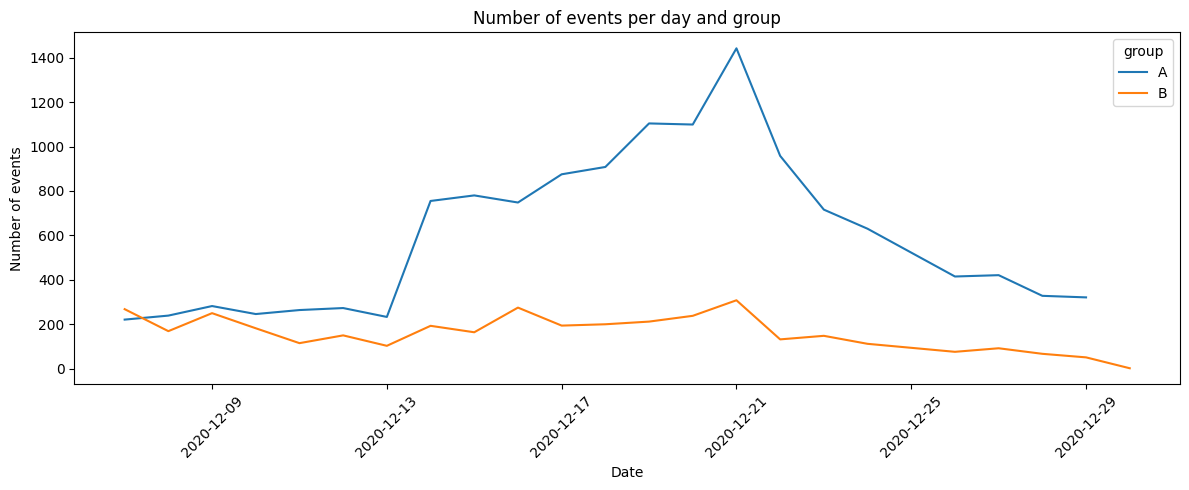

In [43]:
# Se evalúan los picos, caídas o comportamientos atípicos en el tiempo
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=events_by_day, x='event_date', y='events_count', hue='group')
plt.title('Number of events per day and group')
plt.xlabel('Date')
plt.ylabel('Number of events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa que, en general, hay una mayor cantidad de participantes en el grupo A que en el grupo B, donde destaca un pico importante el 21 de diciembre del año 2020. Puede deberse a que el grupo A, por ser el grupo de control, ha estado más tiempo en existencia y por ello ha sido susceptible de recibir más participantes respecto del grupo B.

Antes del filtrado de participantes, había 2604 registros en el grupo A y 877 en el grupo B, lo que generó un desbalance inicial de 74.8 % y 25.2 % entre los grupos, respectivamente. Luego del filtrado de participantes, había 1939 registros en el grupo A y 655 en el grupo B, lo que generó un desbalance inicial de 74.8 % y 25.2 % entre los grupos, lo que significa que este desbalance no fue causado por el filtrado realizado (ya que las proporciones se han mantenido prácticamente idénticas), sino que ya existía desde la creación de la prueba. Podría reducirse la cantidad de participantes del grupo A a una cantidad similar a la que posee el grupo B para que la proporción esté equilibrada; sin embargo, significaría aplicar una pérdida masiva intencional de datos, lo cual podría reducir el poder estadístico de la prueba (además de la posibilidad de generar un sesgo de selección al usar alguna metodología de elección de registros a eliminar). En conclusión, se optará por continuar con el análisis con los registros actuales de ambos grupos, pero tomando en cuenta dicho desbalance para la aplicación de métodos estadísticos apropiados en casos de grupos desbalanceados como este.

### 4.3. Construcción del embudo de conversión

#### 4.3.1. Identificación de etapas del embudo

In [44]:
# Se definirán las etapas clave para el análisis de embudo: product_page, product_cart y purchase
funnel_events = ['product_page', 'product_cart', 'purchase']

#### 4.3.2. Cálculo de usuarios por etapa

In [45]:
# Se procede a calcular cuántos usuarios alcanzan cada etapa del embudo
funnel = (ab_events[ab_events['event_name'].isin(funnel_events)].groupby(['group', 'event_name'])['user_id']
    .nunique().reset_index())

funnel

,group,event_name,user_id
0,A,product_cart,589
1,A,product_page,1265
2,A,purchase,613
3,B,product_cart,184
4,B,product_page,367
5,B,purchase,191


### 4.4. Cálculo de tasas de conversión

#### 4.4.1. Conversión no secuencial

In [46]:
# Se calculan los usuarios únicos que realizaron cada actividad del embudo (no necesariamente habiendo participado en los 3 eventos)
funnel_pivot = funnel.pivot(index='group', columns='event_name', values='user_id')
funnel_pivot = funnel_pivot.reindex(columns=['product_page', 'product_cart', 'purchase'])
funnel_pivot

event_name,product_page,product_cart,purchase
group,,,
A,1265,589,613
B,367,184,191


Se observa que la cantidad de usuarios con evento purchase es mayor que la de aquellos con product_cart, lo cual sugiere que algunos usuarios realizaron compras sin pasar explícitamente por el carrito de compras. Por ello, además del análisis general por eventos, se elaborará un embudo secuencial estricto para evaluar únicamente a los usuarios que siguieron la secuencia completa del flujo.

#### 4.4.2. Conversión secuencial

Se procede ahora a identificar la cantidad de usuarios únicos que participó en cada evento del embudo (ahora con la estricta condición de queprovengan de la actividad previa).

In [47]:
# Se procede a crear set de usuarios por evento, para ello se crea una función para aplicarla en cada grupo
def sequential_funnel(data, group_name):

    group_data = data[data['group'] == group_name]
    
    page_users = set(group_data[group_data['event_name'] == 'product_page']['user_id'])
    cart_users = set(group_data[group_data['event_name'] == 'product_cart']['user_id'])
    purchase_users = set(group_data[group_data['event_name'] == 'purchase']['user_id'])

    # Se analizan ahora a los usuarios que siguieron la secuencia del embudo
    
    # Usuarios que realizaron la actividad product_page
    step_1 = page_users
    
    # Usuarios que, luego del paso anterior, realizaron la actividad product_cart
    step_2 = page_users & cart_users
    
    # Usuarios que, luego del paso anterior, realizaron la actividad purchase
    step_3 = page_users & cart_users & purchase_users
    
    # Visualizamos el tamaño de cada parte del embudo secuencial estricto
    print('Product Page:', len(step_1))
    print('Product Cart:', len(step_2))
    print('Purchase:', len(step_3))

    return {
        'product_page': len(step_1),
        'product_cart': len(step_2),
        'purchase': len(step_3),
        'page_to_cart': round(len(step_2) / len(step_1),3),
        'cart_to_purchase': round(len(step_3) / len(step_2),3),
        'full_conversion': round(len(step_3) / len(step_1),3)
    }    

#### 4.4.2. Conversión total

In [48]:
# Aplicamos la función definida en la celda anterior para determinar la tasa de conversión de los grupos A y B
funnel_A = sequential_funnel(ab_events, 'A')
funnel_B = sequential_funnel(ab_events, 'B')

print(funnel_A)
print(funnel_B)

Product Page: 1265
Product Cart: 389
Purchase: 133
Product Page: 367
Product Cart: 97
Purchase: 34
{'product_page': 1265, 'product_cart': 389, 'purchase': 133, 'page_to_cart': 0.308, 'cart_to_purchase': 0.342, 'full_conversion': 0.105}
{'product_page': 367, 'product_cart': 97, 'purchase': 34, 'page_to_cart': 0.264, 'cart_to_purchase': 0.351, 'full_conversion': 0.093}


### 4.5. Comparación entre grupos

#### 4.5.1. Comparación de conversiones

In [49]:
# Se comparan las tasas de conversión entre los grupos A y B

# Convertimos primero los diccionarios creados en un Dataframe
funnel_seq = pd.DataFrame([funnel_A, funnel_B], index=['A', 'B'])
funnel_seq

,product_page,product_cart,purchase,page_to_cart,cart_to_purchase,full_conversion
A,1265,389,133,0.308,0.342,0.105
B,367,97,34,0.264,0.351,0.093


#### 4.5.2. Visualización de resultados

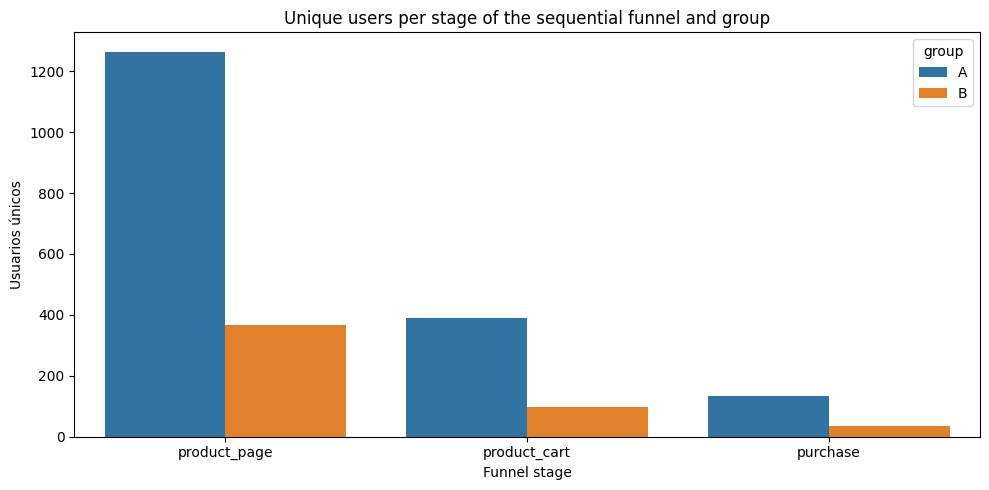

In [50]:
# Se plotean gráficos para facilitar la comparación visual del desempeño de ambos grupos

# Adecuamos el formato del Dataframe creado para poder elaborar una visualización del embudo
funnel_seq_counts = funnel_seq[['product_page', 'product_cart', 'purchase']].reset_index()
funnel_seq_counts = funnel_seq_counts.rename(columns={'index': 'group'})

funnel_seq_counts_long = funnel_seq_counts.melt(id_vars='group', value_vars=['product_page', 'product_cart', 'purchase'],
    var_name='event_name', value_name='users')

plt.figure(figsize=(10, 5))
sns.barplot(data=funnel_seq_counts_long, x='event_name', y='users', hue='group')

plt.title('Unique users per stage of the sequential funnel and group')
plt.xlabel('Funnel stage')
plt.ylabel('Usuarios únicos')
plt.tight_layout()
plt.show()

Encontramos una reducción notoria en los usuarios únicos mientras avanzan por las actividades del embudo planteado (en ambos grupos). Aquí apreciamos también el desbalance existente entre la cantidad de participantes de cada grupo para la prueba A/B a realizar (comentado anteriormente).

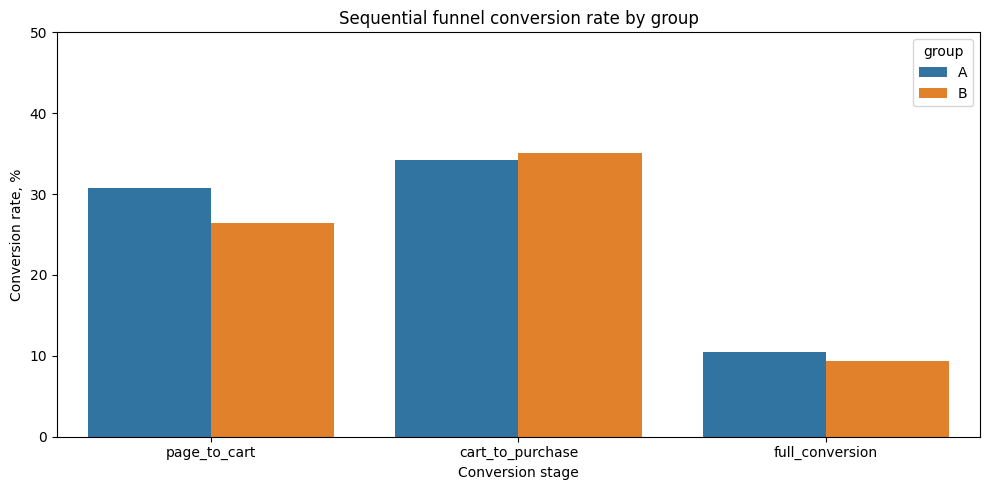

In [51]:
# Se plotean las tasas de conversión entre actividades del embudo para cada grupo
funnel_seq_rates = funnel_seq[['page_to_cart', 'cart_to_purchase', 'full_conversion']].reset_index()
funnel_seq_rates = funnel_seq_rates.rename(columns={'index': 'group'})

funnel_seq_rates_long = funnel_seq_rates.melt(id_vars='group', value_vars=['page_to_cart', 'cart_to_purchase', 'full_conversion'],
    var_name='conversion_stage', value_name='conversion_rate')

funnel_seq_rates_long['conversion_rate_pct'] = funnel_seq_rates_long['conversion_rate'] * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=funnel_seq_rates_long, x='conversion_stage', y='conversion_rate_pct', hue='group')

plt.title('Sequential funnel conversion rate by group')
plt.xlabel('Conversion stage')
plt.ylabel('Conversion rate, %')
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

Aquí encontramos que las tasas de conversión entre actividades (page_to_cart y cart_to_purchase) son parcialmente similares entre sí, lo cual puede brindar una señal positiva de que al menos se mantiene la conversión porcentual entre etapas del embudo; en la última conversión presentada (full_conversion) se refleja lo mostrado en el gráfico anterior: una caída notoria en el poder de lograr concretar ventas en los usuarios únicos. Observamos también que las tasas de conversión de ambos grupos A y B son muy similares (para una misma tasa de conversión) lo cual brinda sustento para intuir que el comportamiento de los participantes de un grupo respecto del otro también es similar; a pesar de que la cantidad de participantes del grupo A es mayor a la del B.

### 4.6. Identificación de anomalías en los datos

#### 4.6.1. Evaluación de inconsistencias

##### Se identifican problemas como desequilibrios de muestra o comportamientos anómalos
Durante el análisis exploratorio se identificaron algunas inconsistencias y particularidades relevantes para la interpretación de la prueba A/B.

Primero, la muestra final utilizada para el análisis quedó conformada por 2594 usuarios válidos: 1939 en el grupo A y 655 en el grupo B. Esta distribución muestra un fuerte desbalance entre grupos, ya que el grupo A concentra aproximadamente tres veces más usuarios que el grupo B. Este punto debe considerarse al interpretar los resultados, porque una muestra más pequeña en el grupo B reduce la estabilidad de sus métricas.

Además, se observó que el número total de participantes válidos es considerablemente menor al número previsto de 6000 usuarios indicado en la descripción técnica de la prueba. Esto sugiere que la prueba no alcanzó el tamaño esperado, lo que puede afectar la potencia estadística del análisis.

También se detectó que 887 usuarios participaron en más de una prueba. Estos usuarios fueron excluidos para evitar la contaminación entre experimentos, ya que su comportamiento pudo haber sido influenciado por condiciones distintas a las de la prueba recommender_system_test.

Otra inconsistencia importante apareció en el análisis inicial del embudo no secuencial: en ambos grupos, el número de usuarios con evento purchase fue mayor que el número de usuarios con evento product_cart. Esto no sigue la lógica estricta del embudo product_page -> product_cart -> purchase, por lo que se interpretó que algunos usuarios pudieron haber realizado compras sin registrar explícitamente un evento de carrito. Para solucionar esta limitación, se construyó un embudo secuencial estricto, considerando únicamente a los usuarios que pasaron por las etapas en orden lógico.

Finalmente, el análisis del embudo secuencial mostró que el grupo B no supera al grupo A en las principales conversiones esperadas. El grupo A presentó una conversión product_page -> product_cart de 30.8%, mientras que el grupo B obtuvo 26.4%. La conversión total del embudo también fue mayor en A (10.5%) que en B (9.3%). Solo en la etapa product_cart -> purchase el grupo B mostró una conversión ligeramente superior, pero la diferencia es pequeña.

#### 4.6.2. Documentación de limitaciones

##### Se documentan los aspectos que puedan afectar la interpretación de los resultados
Los resultados obtenidos deben interpretarse con cautela debido a varias limitaciones detectadas durante la validación y el análisis exploratorio.

En primer lugar, la prueba no alcanzó el tamaño previsto de 6000 participantes. Tras aplicar los filtros necesarios para conservar únicamente usuarios de la región EU y excluir participantes en más de una prueba, la muestra final quedó reducida a 2594 usuarios. Esto puede disminuir la capacidad del experimento para detectar diferencias estadísticamente significativas.

En segundo lugar, existe un desbalance importante entre los grupos A y B. El grupo A contiene 1939 usuarios, mientras que el grupo B contiene solo 655. Aunque las pruebas estadísticas pueden trabajar con tamaños de muestra distintos, este desbalance reduce la precisión de las estimaciones del grupo B.

En tercer lugar, el comportamiento de los eventos no siempre sigue una secuencia estricta. Se encontró que más usuarios realizaron purchase que product_cart, lo que indica que el embudo no debe interpretarse únicamente como una secuencia lineal obligatoria. Por ello, fue necesario diferenciar entre un análisis no secuencial de eventos y un embudo secuencial estricto.

En cuarto lugar, la exclusión de usuarios que participaron en otras pruebas fue necesaria para evitar contaminación experimental, pero también redujo aún más el tamaño muestral disponible.

Por estas razones, los resultados de la prueba A/B deben considerarse con cierta reserva. Aunque el análisis permite evaluar tendencias y diferencias entre grupos, la calidad de la implementación experimental limita la fuerza de las conclusiones.

## Paso 5. Evaluación estadística de la prueba A/B

### 5.1. Definición de la hipótesis

#### 5.1.1. Hipótesis nula

La hipótesis nula establece que el nuevo sistema de recomendaciones implementado en el grupo B no mejora las tasas de conversión del embudo respecto al grupo A.

En otras palabras, se asume que cualquier diferencia observada entre ambos grupos puede explicarse por variabilidad aleatoria y no por un efecto real del nuevo sistema de recomendaciones.

Dado que el objetivo del experimento es evaluar mejoras en el avance de usuarios dentro del embudo secuencial estricto, las hipótesis se formularán sobre las tasas de conversión entre etapas del embudo.

Para cada etapa evaluada, la hipótesis nula puede expresarse como:

H0: La tasa de conversión del grupo B es menor o igual a la tasa de conversión del grupo A.

Esto se evaluará para las siguientes conversiones:
- product_page -> product_cart
- product_cart -> purchase
- product_page -> purchase

Esta formulación ha sido planteada para ser consistente con el objetivo del proyecto, ya que el experimento busca verificar si el nuevo sistema de recomendaciones incrementa el avance de usuarios entre etapas del embudo de compra.

#### 5.1.2. Hipótesis alternativa

La hipótesis alternativa establece que el nuevo sistema de recomendaciones implementado en el grupo B mejora las tasas de conversión del embudo respecto al grupo A.

El objetivo de negocio de la prueba A/B es comprobar si el grupo B logra un mejor desempeño en el embudo de compra, por lo que el análisis estadístico se realizará mediante una prueba unilateral de diferencia de proporciones.

Esto implica que el interés principal del análisis es detectar si las tasas de conversión del grupo B son superiores a las del grupo A.

Para cada etapa evaluada, la hipótesis alternativa puede expresarse como:

H1: La tasa de conversión del grupo B es mayor que la tasa de conversión del grupo A.

Las conversiones analizadas serán:
- product_page -> product_cart
- product_cart -> purchase
- product_page -> purchase

Esta formulación es adecuada porque el resultado esperado del experimento establece explícitamente que el nuevo sistema de recomendaciones debería generar un aumento en las conversiones del embudo.

Además, el análisis exploratorio previo mostró que el grupo B no presenta mejoras claras respecto al grupo A en varias etapas del embudo, por lo que la prueba estadística permitirá evaluar si las diferencias observadas son suficientemente grandes como para atribuirse a un efecto real del sistema de recomendaciones y no al azar.

### 5.2. Cálculo de proporciones

#### 5.2.1. Proporción por grupo

In [52]:
# Se construyen las conversiones del embudo secuencial

funnel_seq['page_to_cart_conversion'] = (funnel_seq['product_cart'] / funnel_seq['product_page'])
funnel_seq['cart_to_purchase_conversion'] = (funnel_seq['purchase'] / funnel_seq['product_cart'])
funnel_seq

,product_page,product_cart,purchase,page_to_cart,cart_to_purchase,full_conversion,page_to_cart_conversion,cart_to_purchase_conversion
A,1265,389,133,0.308,0.342,0.105,0.307510,0.341902
B,367,97,34,0.264,0.351,0.093,0.264305,0.350515


Se han calculado las tasas de conversión del embudo secuencial estricto para ambos grupos.

A diferencia del análisis previo de eventos independientes, estas conversiones consideran únicamente a los usuarios que avanzaron de manera lógica entre etapas del embudo.

Las conversiones evaluadas fueron:
- product_page -> product_cart
- product_cart -> purchase
- product_page -> purchase

Este enfoque es más consistente con el objetivo del experimento, ya que permite medir directamente la capacidad del nuevo sistema de recomendaciones para mejorar el avance de usuarios dentro del embudo de compra.

### 5.3. Aplicación de prueba z

#### 5.3.1. Comparación de proporciones

In [53]:
# Se aplica una prueba z para comparar las tasas de conversión entre grupos en cada etapa del embudo
def z_test(successes_a, successes_b, trials_a, trials_b):
    p1 = successes_a / trials_a
    p2 = successes_b / trials_b
    p_combined = (successes_a + successes_b) / (trials_a + trials_b)
    difference = p2 - p1
    se = np.sqrt(p_combined * (1 - p_combined) * (1/trials_a + 1/trials_b))
    z_value = difference / se

    # Prueba unilateral: B > A
    p_value = 1 - st.norm.cdf(abs(z_value))
    return z_value, p_value

In [54]:
# Se procede a analizar la tasa de conversión page_to_cart
z_page_cart, p_page_cart = z_test(successes_a=funnel_seq.loc['A', 'product_cart'],
    successes_b=funnel_seq.loc['B', 'product_cart'], trials_a=funnel_seq.loc['A', 'product_page'],
    trials_b=funnel_seq.loc['B', 'product_page'])

print('PAGE -> CART')
print('z-value:', z_page_cart)
print('p-value:', p_page_cart)

PAGE -> CART
z-value: -1.5935253103020854
p-value: 0.055521197490911


In [55]:
# Se procede a analizar la tasa de conversión cart_to_purchase
z_cart_purchase, p_cart_purchase = z_test(successes_a=funnel_seq.loc['A', 'purchase'],
    successes_b=funnel_seq.loc['B', 'purchase'],trials_a=funnel_seq.loc['A', 'product_cart'],
    trials_b=funnel_seq.loc['B', 'product_cart'])

print('CART -> PURCHASE')
print('z-value:', z_cart_purchase)
print('p-value:', p_cart_purchase)

CART -> PURCHASE
z-value: 0.15980385462515234
p-value: 0.436517793777769


In [56]:
# Se procede a analizar la tasa de conversión full_conversion
z_full, p_full = z_test(successes_a=funnel_seq.loc['A', 'purchase'],
    successes_b=funnel_seq.loc['B', 'purchase'], trials_a=funnel_seq.loc['A', 'product_page'],
    trials_b=funnel_seq.loc['B', 'product_page'])

print('PAGE -> PURCHASE')
print('z-value:', z_full)
print('p-value:', p_full)

PAGE -> PURCHASE
z-value: -0.6953566300155363
p-value: 0.24341591646184013


### 5.4. Ajuste por comparaciones múltiples

#### 5.4.1. Control del error tipo I

In [57]:
# Se aplica la corrección de Bonferroni para evitar falsos positivos debido a múltiples comparaciones
alpha = 0.05
n_tests = 3
alpha_bonferroni = alpha / n_tests

round(alpha_bonferroni,4)

0.0167

Debido a que se realizaron múltiples pruebas estadísticas sobre distintas etapas del embudo, se aplicó una corrección de Bonferroni para controlar el riesgo de error tipo I.

El nivel de significancia original elegido fue del 5 % ya que el analizar tasas de conversión de un embudo secuencial es una labor típica para este tipo de pruebas y se considera que no requiere una significancia más estricta. Dado que se realizaron 3 comparaciones, el nuevo umbral ajustado fue:

significancia ajustada = 0.05 / 3 = 0.0167

De esta manera, solo se considerarán estadísticamente significativas aquellas pruebas cuyo p-value sea menor a 0.0167.

### 5.5. Interpretación de resultados

#### 5.5.1. Evaluación de p-values

Se analizan los valores p para determinar la significancia estadística.

In [58]:
# Se crea un Dataframe para ordenar y presentar los resultados del p_value y respuesta de si se alcanzo la significancia esperada

results = pd.DataFrame({'comparison': ['page_to_cart', 'cart_to_purchase', 'page_to_purchase'], 'p_value': [p_page_cart,
        p_cart_purchase, p_full]})
results['significant'] = (results['p_value'] < alpha_bonferroni)

results

,comparison,p_value,significant
0,page_to_cart,0.055521,False
1,cart_to_purchase,0.436518,False
2,page_to_purchase,0.243416,False


Los p-values obtenidos fueron comparados con el nivel de significancia ajustado mediante la corrección de Bonferroni.

En todas las tasas de conversión se encontró que el p-value fue mayor a la significancia ajustada (0.0167), por lo que no existe evidencia suficiente para afirmar que las conversiones entre grupos son diferentes entre sí.

#### 5.5.2. Evaluación de magnitud del efecto

In [59]:
# Se analiza el incremento absoluto de conversión
effect_page_cart = (funnel_seq.loc['B', 'page_to_cart_conversion'] - funnel_seq.loc['A', 'page_to_cart_conversion'])

effect_cart_purchase = (funnel_seq.loc['B', 'cart_to_purchase_conversion'] - funnel_seq.loc['A', 'cart_to_purchase_conversion'])

effect_full = (funnel_seq.loc['B', 'full_conversion'] - funnel_seq.loc['A', 'full_conversion'])

print('Effect PAGE -> CART:', round(effect_page_cart, 4))
print('Effect CART -> PURCHASE:', round(effect_cart_purchase, 4))
print('Effect PAGE -> PURCHASE:', round(effect_full, 4))

Effect PAGE -> CART: -0.0432
Effect CART -> PURCHASE: 0.0086
Effect PAGE -> PURCHASE: -0.012


In [60]:
# Se analiza el incremento porcentual de conversión
uplift_page_cart = (effect_page_cart /funnel_seq.loc['A', 'page_to_cart_conversion']) * 100

uplift_cart_purchase = (effect_cart_purchase /funnel_seq.loc['A', 'cart_to_purchase_conversion']) * 100

uplift_full = (effect_full / funnel_seq.loc['A', 'full_conversion']) * 100

print('Uplift PAGE -> CART:', round(uplift_page_cart, 2))
print('Uplift CART -> PURCHASE:', round(uplift_cart_purchase, 2))
print('Uplift PAGE -> PURCHASE:', round(uplift_full, 2))

Uplift PAGE -> CART: -14.05
Uplift CART -> PURCHASE: 2.52
Uplift PAGE -> PURCHASE: -11.43


Además de evaluar la significancia estadística, se analizó la magnitud práctica de las diferencias observadas entre los grupos.

Para ello se calculó el uplift porcentual del grupo B respecto al grupo A en cada etapa del embudo.

Este análisis permite determinar si las diferencias observadas no solo son estadísticamente significativas, sino también relevantes desde el punto de vista del negocio.

El objetivo esperado del experimento era alcanzar al menos un incremento del 10% en las conversiones del grupo B, sin embargo, según los resultados incluso se encuentran conversiones del grupo B que empeoran respecto del grupo A (específicamente en las conversiones PAGE -> CART y PAGE -> PURCHASE), siendo concluyente entonces (dentro de las limitaciones descritas en el EDA) que no mejoraría la tasa de conversión entre los eventos del embudo principal con el cambio relacionado en el sistema de recomendaciones de la plataforma.

## Paso 6. Conclusiones

### 6.1. Conclusiones sobre la calidad de la prueba

##### Se evaluará si la prueba A/B fue implementada correctamente y si los resultados son confiables.
La validación de la prueba A/B permitió identificar varias limitaciones importantes que deben considerarse antes de interpretar los resultados del experimento.

En primer lugar, la prueba no alcanzó el tamaño esperado de 6000 participantes indicado en la descripción técnica. Luego de aplicar los filtros necesarios para conservar únicamente usuarios válidos de la región EU y excluir usuarios presentes en múltiples pruebas, la muestra final quedó conformada por 2594 participantes.

Además, se observó un fuerte desbalance entre los grupos experimentales. El grupo A quedó compuesto por 1939 usuarios, mientras que el grupo B solo contó con 655 usuarios. Esto implica que aproximadamente el 74.7 % de los participantes pertenecían al grupo A y solo el 25.3 % al grupo B, lo cual puede afectar la estabilidad y precisión de las métricas del grupo experimental.

También se detectó la presencia de usuarios registrados en múltiples pruebas A/B. Debido a que esto podía generar contaminación experimental y afectar el comportamiento natural de los usuarios, dichos participantes fueron excluidos del análisis final.

Otro aspecto importante fue la detección de un comportamiento no estrictamente secuencial en los eventos del embudo. Inicialmente se observó que el número de usuarios con evento purchase era superior al número de usuarios con evento product_cart, lo cual no seguía la lógica esperada del embudo. Esto sugirió la existencia de compras directas sin pasar explícitamente por el carrito. Por ello, se decidió complementar el análisis con un embudo secuencial estricto, permitiendo evaluar únicamente a los usuarios que siguieron el flujo lógico completo.

Finalmente, la distribución temporal de eventos mostró un volumen considerablemente mayor de actividad en el grupo A respecto al grupo B durante prácticamente todo el periodo analizado. Esto refuerza la existencia de un desbalance estructural entre grupos y constituye una limitación adicional para la interpretación de la prueba.

### 6.2. Conclusiones sobre el embudo de conversión

##### Se describirá el comportamiento de los usuarios en cada etapa del embudo.
El análisis del embudo secuencial estricto permitió evaluar el avance real de los usuarios entre las distintas etapas del proceso de compra.

En la etapa product_page -> product_cart, el grupo A obtuvo una tasa de conversión de 30.8 %, mientras que el grupo B alcanzó una tasa de 26.4 %. Esto indica que el grupo experimental no logró mejorar la transición de usuarios hacia el carrito de compras; por el contrario, presentó un desempeño inferior al grupo de control.

En la etapa product_cart -> purchase, ambos grupos presentaron resultados bastante similares. El grupo A alcanzó una conversión de 34.2 %, mientras que el grupo B obtuvo 35.1 %. Aunque el grupo B muestra una ligera mejora en esta etapa, la diferencia es pequeña y no representa un incremento considerable.

Respecto a la conversión total del embudo (product_page -> purchase), el grupo A obtuvo una tasa de 10.5 %, mientras que el grupo B alcanzó 9.3 %. Esto indica nuevamente que el nuevo sistema de recomendaciones no produjo una mejora global del embudo de compra.

En términos generales, los resultados exploratorios muestran que el grupo B no logró alcanzar el objetivo esperado de incrementar las conversiones en al menos un 10 % respecto al grupo A. Las diferencias observadas fueron pequeñas y, en la mayoría de los casos, desfavorables para el grupo experimental.

### 6.3. Conclusiones sobre la prueba estadística

##### Se determinará si existen diferencias significativas entre los grupos
Para evaluar formalmente si las diferencias observadas entre los grupos eran estadísticamente significativas, se aplicó una prueba z unilateral sobre las tasas de conversión del embudo secuencial estricto.

El análisis se realizó bajo el supuesto de que el grupo B debía superar al grupo A en las distintas etapas del embudo, ya que el objetivo del experimento era validar si el nuevo sistema de recomendaciones generaba una mejora en las conversiones.

En la conversión product_page -> product_cart, se obtuvo un p-value de aproximadamente 0.0555. Este valor es superior tanto al nivel de significancia convencional (0.05) como al nivel ajustado mediante corrección de Bonferroni (0.0167). Por ello, no existe evidencia estadísticamente significativa para afirmar que el grupo B mejora la conversión hacia el carrito de compras.

En la conversión product_cart → purchase, se obtuvo un p-value de aproximadamente 0.4365, valor considerablemente superior al umbral de significancia. Esto indica que tampoco existe evidencia estadística de una mejora real del grupo B en la etapa final del embudo.

En consecuencia, no se logró rechazar la hipótesis nula en ninguna de las etapas analizadas. Los resultados sugieren que las diferencias observadas entre ambos grupos pueden atribuirse a variabilidad aleatoria y no a un efecto real del nuevo sistema de recomendaciones.

Por lo tanto, desde el punto de vista estadístico, la prueba A/B no proporciona evidencia suficiente para concluir que el nuevo sistema implementado en el grupo B mejora las conversiones del embudo de compra.

### 6.4. Recomendación final

##### Se presentará una conclusión de negocio sobre la conveniencia de implementar el nuevo sistema de recomendaciones
Considerando tanto los resultados exploratorios como los resultados estadísticos obtenidos, no se recomienda implementar el nuevo sistema de recomendaciones evaluado en el grupo B.

El análisis del embudo secuencial mostró que el grupo experimental no presentó mejoras claras respecto al grupo de control en las principales etapas del proceso de compra. Además, las pruebas estadísticas indicaron que las diferencias observadas no son estadísticamente significativas.

Adicionalmente, la calidad de la implementación experimental presentó varias limitaciones importantes, como:
- tamaño muestral menor al esperado,
- fuerte desbalance entre grupos,
- presencia inicial de usuarios en múltiples pruebas,
- comportamiento no estrictamente secuencial de los eventos del embudo.

Estas limitaciones reducen la confiabilidad del experimento y dificultan extraer conclusiones sólidas sobre el impacto real del nuevo sistema de recomendaciones.

Por ello, antes de considerar una nueva implementación, sería recomendable:
- ejecutar nuevamente la prueba con una asignación más equilibrada entre grupos,
- asegurar exclusividad de usuarios entre experimentos,
- aumentar el tamaño muestral,
- validar previamente la estructura y consistencia del embudo de eventos.

Solo después de corregir estas limitaciones sería posible evaluar de manera más robusta el verdadero efecto del sistema de recomendaciones sobre las conversiones de los usuarios.